<a href="https://colab.research.google.com/github/diyamodi595/CodeAlpha_DiseasePrediction/blob/main/CodeAlpha_Disease_Prediction_from_Medical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Age  Blood_Pressure  Sugar_Level  Cholesterol  Heart_Rate  Disease
0   45             140          180          240          90        1
1   50             150          200          260          95        1
2   35             120          110          180          75        0
3   60             160          220          280         100        1
4   40             130          130          200          80        0

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
[[3]]

New Patient Prediction:
Disease Risk Detected


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


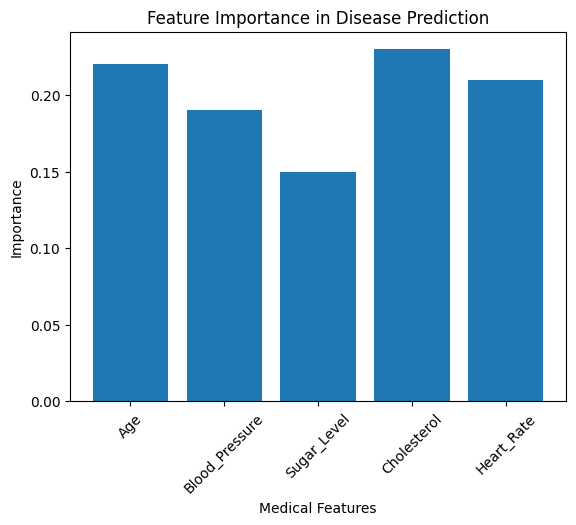

In [1]:
# Disease Prediction from Medical Data
# CodeAlpha Internship Project - Task 4

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


# -----------------------------------
# 1. Create Medical Dataset
# -----------------------------------

data = {
    "Age": [45,50,35,60,40,55,30,65,48,52,
            38,70,33,58,42],

    "Blood_Pressure": [140,150,120,160,130,155,110,170,145,150,
                       125,180,115,165,135],

    "Sugar_Level": [180,200,110,220,130,210,100,250,190,205,
                    120,260,105,230,140],

    "Cholesterol": [240,260,180,280,200,270,170,300,250,265,
                    190,320,160,290,210],

    "Heart_Rate": [90,95,75,100,80,98,70,105,92,96,
                   78,110,72,102,82],

    # 1 = Disease Present, 0 = No Disease
    "Disease": [1,1,0,1,0,1,0,1,1,1,
                0,1,0,1,0]
}


df = pd.DataFrame(data)

print(df.head())


# -----------------------------------
# 2. Split Data
# -----------------------------------

X = df.drop("Disease", axis=1)
y = df["Disease"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -----------------------------------
# 3. Train Model
# -----------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)


# -----------------------------------
# 4. Prediction
# -----------------------------------

y_pred = model.predict(X_test)


# -----------------------------------
# 5. Model Evaluation
# -----------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# -----------------------------------
# 6. Test New Patient Data
# -----------------------------------

new_patient = np.array([[50,150,190,250,95]])

prediction = model.predict(new_patient)


print("\nNew Patient Prediction:")

if prediction[0] == 1:
    print("Disease Risk Detected")
else:
    print("No Disease Risk")


# -----------------------------------
# 7. Feature Importance Graph
# -----------------------------------

importance = model.feature_importances_

plt.bar(
    X.columns,
    importance
)

plt.xlabel("Medical Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Disease Prediction")

plt.xticks(rotation=45)
plt.show()